# Classification: Benchmarking
- Loads YOLO, ViT and CNN models
- Test the models on the test set (from the '30kds')
- Plots confusion matrix for each model
- Compare acc and loss
- Runs on CPU

In [3]:
%matplotlib inline
import os
import torch
import timm
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, accuracy_score
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_dir = "30kds/test"

In [4]:
# Define transformation for CNN and ViT
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_dataset = ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class_names = test_dataset.classes  # ['Fake', 'Real']

In [5]:
# Load Models
def load_cnn(model_path):
    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)  # Binary classification
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def load_vit(model_path):
    model = timm.create_model("vit_base_patch16_224", num_classes=2)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def load_yolo(model_path):
    model = YOLO(model_path)
    return model

In [6]:
# Model Evaluation Function
def evaluate_model(model, model_name, is_yolo=False):
    if is_yolo:
        print(f"Running YOLO validation for {model_name}...")

        # Run YOLO's built-in validation and get metrics
        results = model.val(data="30kds", split="test", verbose=False)
        cm = results.confusion_matrix.matrix
        acc = results.results_dict.get("metrics/accuracy_top1", 0)

        return acc, cm

    # Regular CNN/ViT evaluation
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return acc, cm

# Load and Evaluate Models
models_dict = {
    "CNN": ("models/resnet_classifier.pth", load_cnn),
    "ViT": ("models/vit_classifier_small.pth", load_vit),
    "YOLO": ("models/best.pt", load_yolo)
}

results = {}
for model_name, (model_path, loader) in models_dict.items():
    if os.path.exists(model_path):
        print(f"Loading {model_name} from {model_path}")
        model = loader(model_path)
        is_yolo = model_name == "YOLO"
        acc, cm = evaluate_model(model, model_name, is_yolo)
        results[model_name] = {"accuracy": acc, "confusion_matrix": cm}
    else:
        print(f"Model {model_name} not found! Skipping...")

Loading CNN from models/resnet_classifier.pth


Evaluating CNN: 100%|██████████| 177/177 [00:27<00:00,  6.35it/s]


Loading ViT from models/vit_classifier_small.pth


Evaluating ViT: 100%|██████████| 177/177 [00:35<00:00,  4.96it/s]

Loading YOLO from models/best.pt
Running YOLO validation for YOLO...
Ultralytics 8.3.86  Python-3.10.15 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4080 Laptop GPU, 12282MiB)


YOLO11s-cls summary (fused): 47 layers, 5,436,690 parameters, 0 gradients, 12.0 GFLOPs
train: C:\Users\danie\Desktop\UNI-4ano\DL\30kds\train... found 40521 images in 2 classes  
val: C:\Users\danie\Desktop\UNI-4ano\DL\30kds\val... found 5653 images in 2 classes  
test: C:\Users\danie\Desktop\UNI-4ano\DL\30kds\test... found 5656 images in 2 classes  


test: Scanning C:\Users\danie\Desktop\UNI-4ano\DL\30kds\test... 5656 images, 0 corrupt: 100%|██████████| 5656/5656 [00:00<?, ?it/s]

test: WARNING  C:\Users\danie\Desktop\UNI-4ano\DL\30kds\test\Real\53045_Real.png: corrupt JPEG restored and saved



               classes   top1_acc   top5_acc: 100%|██████████| 354/354 [00:10<00:00, 34.45it/s]


                   all       0.99          1
Speed: 0.3ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\val10



CNN Accuracy: 0.9818


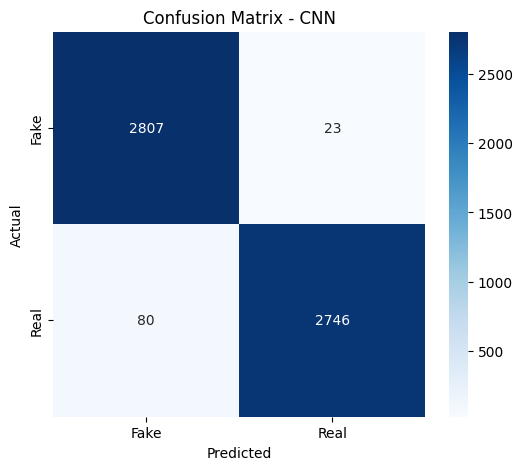


ViT Accuracy: 0.8808


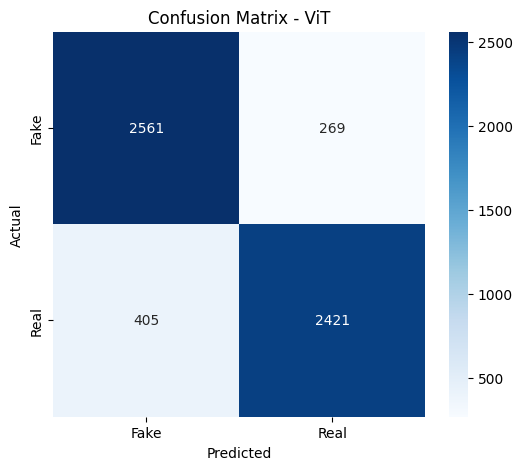


YOLO Accuracy: 0.9899


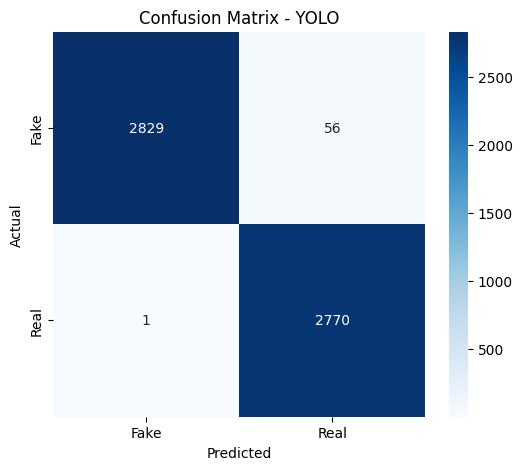

In [7]:
# Plot Confusion Matrices
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 5))
    
    if cm.dtype == np.float64 or cm.dtype == np.float32:
        cm = cm.astype(int)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show(block=True)

for model_name, data in results.items():
    print(f"\n{model_name} Accuracy: {data['accuracy']:.4f}")
    plot_confusion_matrix(data["confusion_matrix"], model_name)